# Quantum-electrodynamical time-dependent density functional theory within Gaussian atomic basis - A tutorial for TDA-JC, RWA, Rabi, and PF

**Created by:** Khang Luong  
**Department of Chemistry, Brandeis University**  
#### **Reference:** https://doi.org/10.1063/5.0057542
---
## Overview
This tutorial examines the effect of Tamm-Dancoff approximation with Jaynes-Cummings (TDA-JC), rotating-wave approximation (RWA), Rabi, and Pauli-Fierz (PF) to model polariton spectrum of molecules in polaritons cavities.

By the end of this tutorial, you will be able to: 

1. **Part 1 -** Configuration and TDA-JC Basics
2. **Part 2 -** Polariton spectrum as a function of coupling strength 
3. **Part 3 -** TDA-RWA application 
4. **Part 4 -** TDA-Rabi application
5. **Part 5 -** Recommended Exercises

---
## Environment Setup
### 1. (Optional) Create a Virtual Environment
It is recommended to use a virtual environment to avoid package conflicts. 

In, your terminal, run:

```bash
python3 -m venv venv
```
Next, activate the virtual environment with one of these commands.

MacOS:

```bash
source venv/bin/activate
```

Windows:

```bash
.venv\Scripts\activate
```

### 2. Install Dependencies
Install all required Python packages using:

```bash
pip install -r requirements.txt
```

### 3. Select the Jupyter Kernel
In the top-right corner of the notebook: 
1. Click **Kernel**
2. Select **Change Kernel**
3. Choose the `.venv` environment you just created

### Verify Installation
Run the following cell to import all required libraries and confirm that the environment is configured correctly.

### 📦 Imports & Configuration

In [1]:
import numpy as np
from pyscf import gto, scf, tdscf
import scipy
import qed
#pip install qed later. 
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Color for printing
RED    = "\033[91m"
GREEN  = "\033[92m"
YELLOW = "\033[93m"
BLUE   = "\033[94m"
RESET  = "\033[0m"

#Unit Conversion:
HF_TO_EV = 27.2114
EV_TO_HF = 1 / HF_TO_EV

print("✅ All the imports are successful!")

✅ All the imports are successful!


--- 
# 🗂️ Part 1: Configuration
## 1.1 Molecular Structure and Ground State Calculation
We can specify the structure and basis of the molecule directly in the follow code block or any structural file. Then, we run the ground state SCF calculation:

In [2]:
mol_file = 'ethene.xyz'  # Replace with your molecule file path
mol = gto.M(atom=mol_file, basis='6-311++G')
mf = scf.RKS(mol)
mf.xc = 'pbe0'
mf.kernel()

converged SCF energy = -76.6624395042443


np.float64(-76.66243950424428)

## 1.2 Setup Standard TDA (Electronic only)

Under the Tamm-Dancoff approximation (TDA), the de-excitation block can be set to zero, resulting the TDA - PF (Tamm-Dancoff approximation Pauli-Fierz) model

$$
\begin{bmatrix}
\mathbf{A} + \Delta & \hbar \mathbf{g}^{\dagger} & \hbar \tilde{\mathbf{g}}^{\dagger} \\
\hbar \mathbf{g} & \hbar \mathbf{\omega} & 0 \\
\hbar \tilde{\mathbf{g}} & 0 & \hbar \mathbf{\omega}
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M} \\ \mathbf{N}
\end{bmatrix}
=
\hbar\Omega^{\text{TDA-PF}}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & -1 
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M} \\ \mathbf{N}
\end{bmatrix}

\tag{1}
$$

where: 
+ $\mathbf{A}$ is the standard TDDFT electronic excitation matrix.
+ $\hbar\mathbf{\omega}$ is a diagonal matrix containing the cavity photon frequencies
+ $\mathbf{X}$ and $\mathbf{M}$ are the transition amplitudes for the electron and the dimensionless photon phase, respectively.
+ $\mathbf{g}$ is the electron-photon coupling strength.

If we further remove the dipole self-energy (DSE) $\Delta$, we can obtain the TDA-Rabi model

$$
\begin{bmatrix}
\mathbf{A} & \hbar \mathbf{g}^{\dagger} & \hbar \tilde{\mathbf{g}}^{\dagger} \\
\hbar \mathbf{g} & \hbar \mathbf{\omega} & 0 \\
\hbar \tilde{\mathbf{g}} & 0 & \hbar \mathbf{\omega}
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M} \\ \mathbf{N}
\end{bmatrix}
=
\hbar\Omega^{\text{TDA-Rabi}}
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & -1 
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M} \\ \mathbf{N}
\end{bmatrix}

\tag{2}
$$

If we neglect the counter-rotation terms (CRTs) $\hbar \tilde{\mathbf{g}}^{\dagger}$, we obtain the rotating wave approximation (RWA)

$$
\begin{bmatrix}
\mathbf{A} + \Delta & \hbar \mathbf{g}^{\dagger}\\
\hbar \mathbf{g} & \hbar \mathbf{\omega}
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M}
\end{bmatrix}
=
\hbar\Omega^{\text{TDA-RWA}}
\begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M}
\end{bmatrix}

\tag{3}
$$

If both the DSE and CRT terms are negleted, we obtain the TDA-JC model 

$$
\begin{bmatrix}
\mathbf{A} & \hbar \mathbf{g}^{\dagger}\\
\hbar \mathbf{g} & \hbar \mathbf{\omega}
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M}
\end{bmatrix}
=
\hbar\Omega^{\text{TDA-JC}}
\begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\mathbf{X} \\ \mathbf{M}
\end{bmatrix}

\tag{4}
$$

## 1.3 Computational Workflow
### 1.3.1 Calculate Transition Dipole
1. We first need to construct the excited state solver on top of the mean-field object referece and obtain the excitation energies from the TDA eigenvalue equation.
2. Next, we compute the oscillator strengths, which measures how strongly light couples to a transition
$$
f_I = \frac{2}{3}\omega_I|\mu_{0I}|^2
$$
3. Then, we get the largest oscillator strength to compute the transition dipole moments, which is defined as
$$
\mathbf{\mu}_I^{\text{TDA-JC}}=\sum_{ai}X^{\text{TDA-JC}}_{I,ai}\mathbf{\mu}_{ai}
$$

In [3]:
td = tdscf.TDA(mf)
td.nroots = 5 # Request 5 exicted states
td.kernel()

osc = td.oscillator_strength() # Compute oscillator strengths for each excitation
bright_idx = np.argmax(osc)
target_energy = td.e[bright_idx]

# Get transition dipole moment for the brightest excitation
trans_dip = td.transition_dipole()[bright_idx]
print(f"Targeting bright state: {bright_idx}, at {target_energy:.4f} a.u.")
print(f"Transition dipole moment (a.u.): {trans_dip}")

Excitation energies (eV)
[ 9.103047  9.81183   9.889254 10.281365 10.91316 ]
Targeting bright state: 0, at 0.3345 a.u.
Transition dipole moment (a.u.): [-1.623736e-11  3.725724e-16  5.813733e-01]


Next, we need to solve the full ab initio QED-TDDFT equations in the molecular orbital basis (Equation 4) 

### 1.3.2 Setup QED-TDA with JC Model

The TDA-JC method from ```qed``` package require a key which can contains:
| Category | Key | Type | Default | Description |
| --- | --- | --- | --- | --- |
| **Physical** | `cavity_freq` | float / array | **Required** | Photon mode energy in atomic units (Hartree). |
| | `cavity_mode` | array (3, N) | **Required** | Vector(s) defining coupling direction and vacuum field strength $\mathbf{\lambda}$. |
| | `cavity_model` | string | `'JC'` | Choice of Hamiltonian: `'JC'`, `'RWA'`, `'Rabi'`, or `'PF'`. |
| | `uniform_field` | boolean | `True` | Whether the vacuum field is spatially uniform across the molecule. |
| **Solver** | `nstates` | integer | `4` | Total number of **polaritonic** roots (eigenvalues) to solve for. |
| | `target_states` | string | `'polariton'` | Type of states to extract (e.g., `'polariton'`, `'exciton'`). |
| | `solver_algorithm`| string | `'davidson_qr'`| Algorithm: `'davidson_qr'` (ab initio) or `'direct'` (FewLevel). |
| | `tolerance` | float | `1e-8` | Convergence threshold for the eigenvalue solver residual. |
| | `max_cycle` | integer | `100` | Maximum iterations allowed for iterative solvers. |
| | `level_shift` | float | `0.0` | Numerical shift applied to diagonal elements to aid convergence. |
| **Tuning** | `resonance_state`| integer | `None` | Index of the TDA electronic state to which the photon should be tuned. |
| | `adjust_func` | string | `None` | Tuning strategy for frequency (e.g., `'average'`). Requires `resonance_state`.|
| **Collective**| `has_offdiag` | boolean | `False` | Include inter-fragment dipole-dipole interactions between molecules. |
| | `scale_coupling` | float | `0.0` | Scaling factor for coupling strength, typically $1/\sqrt{N_{frag}}$. |

In [4]:
# Calculate unit vector of the transition dipole moment
unit_dip = trans_dip / np.linalg.norm(trans_dip)

#Define Cavity Parameters with lambda = 0.1 a.u. and coupling direction along the transition dipole moment 
lambda_coupling = 0.1  # Coupling strength in atomic units
cavity_mode = (unit_dip * lambda_coupling).reshape(3, 1)  # Cavity mode vector along the transition dipole direction

key = {
    'cavity_mode': cavity_mode,
    'cavity_freq': np.array([target_energy]),
}

# Construct TDA-JC Model with qed package
cav_model = qed.JC(mf, key)
qed_td = qed.TDA(mf, td, cav_model, key)

# Run Calculation
qed_td.nroots = 8
qed_td.kernel()

scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedJaynesCummings Polariton State energies (au)
[0.3014   0.349993 0.360578 0.363423 0.377833 0.396349 0.401051 0.402273]


(array([0.3014  , 0.349993, 0.360578, 0.363423, 0.377833, 0.396349,
        0.401051, 0.402273]),
 [(array([ 3.149528e-19, -2.081596e-20,  3.881281e-16, -8.753466e-18,
          -2.978311e-16, -3.759402e-05,  1.754323e-18, -3.101466e-18,
           4.428561e-19,  1.933836e-16, -3.635449e-17, -3.330141e-16,
           2.653621e-18, -1.372868e-18,  9.102563e-19,  6.776709e-16,
           3.667523e-18, -3.590810e-18, -9.725166e-17, -1.027203e-04,
           2.465967e-19,  2.093341e-18,  3.014490e-16,  3.062507e-16,
           6.954537e-18,  2.974918e-18,  1.811053e-18, -2.257547e-15,
           4.147651e-19, -4.364804e-16, -5.840517e-19,  3.001847e-19,
           1.466331e-15, -2.495514e-04,  3.446836e-16,  9.606716e-20,
           7.376750e-18,  2.670241e-15, -3.604574e-19,  6.319005e-19,
           5.324043e-18,  3.142656e-17,  3.250070e-16, -1.372143e-18,
           4.123174e-19,  1.372641e-16,  1.009725e-04, -3.843845e-16,
           1.262483e-16, -4.460322e-16, -5.249976e-18,  7.6173

## 1.4 Result

In [5]:
print("JC Polariton Energies (in a.u.):", qed_td.e)

JC Polariton Energies (in a.u.): [0.3014   0.349993 0.360578 0.363423 0.377833 0.396349 0.401051 0.402273]


---
# 🔬 Part 2: Scanning Coupling Strength ($\lambda$)
Before we scan the coupling strength, it is crucial to define our parameters physically. The fundamental coupling strength ($\lambda$) is expressed in atomic units ($e^{-1} a_0^{-1/2}$). 

Physically, increasing $\lambda$ corresponds to a tighter confinement of the electromagnetic field—essentially decreasing the effective mode volume of the optical cavity. This tighter spatial confinement leads to a stronger, more entangled interaction between the vacuum photon field and the molecule's transition dipole moment. 

To ensure maximum resonance, we will dynamically align the cavity polarization vector to perfectly match the molecule's transition dipole unit vector at every step.

In [6]:
lambdas = np.linspace(0.0 , 0.10, 12)
cavity_freqs = np.array([target_energy])

JC_energies = []
JC_photon_contribution = [] 

for lam in lambdas:
    print(f"{GREEN}Coupling lam = {lam:.3f} au...{RESET}", end="\r")
    # 1. Update mode adn re-run TDA-JC
    unit_dip = trans_dip / np.linalg.norm(trans_dip)
    cavity_mode = (unit_dip * lam).reshape(3, 1)
    key = {'cavity_mode': cavity_mode, 'cavity_freq': cavity_freqs}
    cav_jc = qed.JC(mf, key)
    td_jc = qed.TDA(mf, td, cav_jc, key)
    td_jc.nroots = 5
    td_jc.kernel()
    print(f"Coupling: {lam:.3f} a.u., Polariton Energies: {td_jc.e}")
    # 2. Extract energies
    JC_energies.append(td_jc.e)

    # 3. Extract photon contribution
    p = cav_jc.get_mns_weight(td_jc.mn)
    JC_photon_contribution.append(p.flatten())
    print(f"{YELLOW}----------------------------------------------------------------{RESET}")

JC_energies = np.array(JC_energies)
JC_photon_contribution = np.array(JC_photon_contribution)

scf_type: RKS lam = 0.000 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedJaynesCummings Polariton State energies (au)
[0.334531 0.334531 0.360578 0.363423 0.377833]
Coupling: 0.000 a.u., Polariton Energies: [0.334531 0.334531 0.360578 0.363423 0.377833]
----------------------------------------------------------------
scf_type: RKS lam = 0.009 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedJaynesCummings Polariton State energies (au)
[0.33229  0.336614 0.360578 0.363423 0.377833]
Coupling: 0.009 a.u., Polariton Energies: [0.33229  0.336614 0.360578 0.363423 0.377833]
----------------------------------------------------------------
scf_type: RKS lam = 0.018 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedJaynesCummings Polariton State energies (au)
[0.32989  0.338543 0.360578 0.363423 0.377833]
Coupling: 0.018 a.u., Polariton Energies: [0.32989  0.338543 0

## 💡 Generate Plot

+ Since the cavity frequency is tuned excactly to the brightest electronic transition, the photon mode and the electronic state are **degenerate** at $\lambda = 0$
+ When $\lambda > 0$, this degenerate pair splits into the Lower Polariton (Root 0) and Upper Polariton (Root 1)
+ Root 2 is the next electronic state

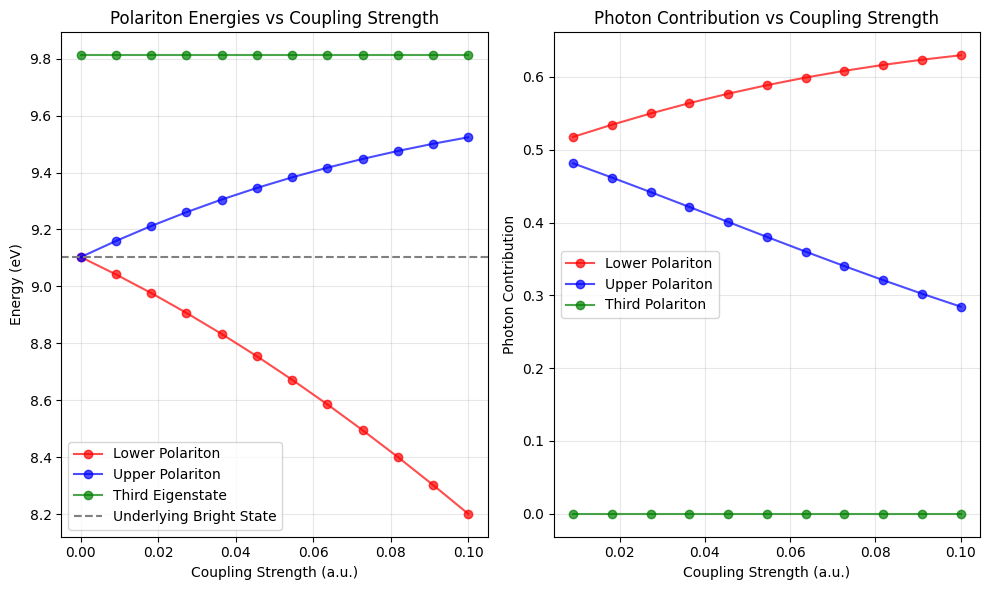

In [7]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

ax1.plot(lambdas, JC_energies[:, 0] * HF_TO_EV, 'ro-', markersize=6, alpha=0.7, label='Lower Polariton')
ax1.plot(lambdas, JC_energies[:, 1] * HF_TO_EV, 'bo-', markersize=6, alpha=0.7, label='Upper Polariton')
ax1.plot(lambdas, JC_energies[:, 2] * HF_TO_EV, 'go-', markersize=6, alpha=0.7, label='Third Eigenstate')
ax1.axhline(target_energy * HF_TO_EV, color='gray', linestyle='--', label='Underlying Bright State')
ax1.set_xlabel('Coupling Strength (a.u.)')
ax1.set_ylabel('Energy (eV)')
ax1.set_title('Polariton Energies vs Coupling Strength')
ax1.legend()
ax1.grid(alpha=0.3)

mask = lambdas >= 1e-8 # Cut low lambda 

ax2.plot(lambdas[mask], JC_photon_contribution[:, 0][mask], 'ro-', markersize=6, alpha=0.7, label='Lower Polariton')
ax2.plot(lambdas[mask], JC_photon_contribution[:, 1][mask], 'bo-', markersize=6, alpha=0.7, label='Upper Polariton')
ax2.plot(lambdas[mask], JC_photon_contribution[:, 2][mask], 'go-', markersize=6, alpha=0.7, label='Third Polariton')
ax2.set_xlabel('Coupling Strength (a.u.)')
ax2.set_ylabel('Photon Contribution')
ax2.set_title('Photon Contribution vs Coupling Strength')
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

---
# Part 3: Tamm-Dancoff with Rotating Wave Approximation (TDA-RWA)

## 3.1 Computational Workflow
Equation 3 is what we need to solve for this method. As such, we can follow the same structure as TDA-JC, but replace the JC attribute with RWA.

In [8]:
cav_rwa = qed.RWA(mf, key)
qed_rwa = qed.TDA(mf, td, cav_rwa, key)

qed_rwa.nroots = 8
qed_rwa.kernel()

print("RWA Polariton Energies (in a.u.):", qed_td.e)

scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedRotatingWaveApproximation Polariton State energies (au)
[0.304595 0.349778 0.360578 0.362552 0.377833 0.394463 0.401051 0.401817]
RWA Polariton Energies (in a.u.): [0.3014   0.349993 0.360578 0.363423 0.377833 0.396349 0.401051 0.402273]


## 3.2 Compare TDA-JC vs TDA-RWA

scf_type: RKS lam = 0.000 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedRotatingWaveApproximation Polariton State energies (au)
[0.334531 0.334531 0.360578 0.363423 0.377833]
Coupling: 0.000 a.u., Polariton Energies: [0.334531 0.334531 0.360578 0.363423 0.377833]
----------------------------------------------------------------
scf_type: RKS lam = 0.009 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedRotatingWaveApproximation Polariton State energies (au)
[0.332304 0.336625 0.360578 0.363422 0.377833]
Coupling: 0.009 a.u., Polariton Energies: [0.332304 0.336625 0.360578 0.363422 0.377833]
----------------------------------------------------------------
scf_type: RKS lam = 0.018 au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedRotatingWaveApproximation Polariton State energies (au)
[0.329952 0.338583 0.360578 0.363417 0.377833]
Coupling: 0.018 a.u., Polarit

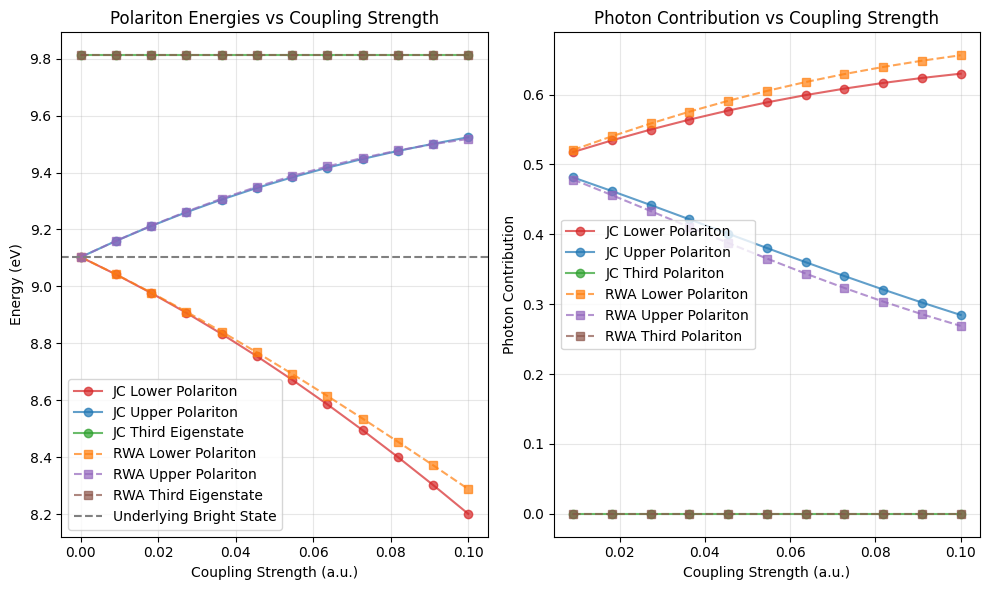

In [9]:
RWA_energies = []
RWA_photon_contribution = []

for lam in lambdas:
    print(f"{GREEN}Coupling lam = {lam:.3f} au...{RESET}", end="\r")
    key['cavity_mode'] = (unit_dip * lam).reshape(3, 1)
    cav_rwa = qed.RWA(mf, key)
    td_rwa = qed.TDA(mf, td, cav_rwa, key)
    td_rwa.nroots = 5
    td_rwa.kernel()
    print(f"Coupling: {lam:.3f} a.u., Polariton Energies: {td_rwa.e}")
    p = cav_rwa.get_mns_weight(td_rwa.mn)
    RWA_photon_contribution.append(p.flatten())
    RWA_energies.append(td_rwa.e)
    print(f"{YELLOW}----------------------------------------------------------------{RESET}")
    
RWA_energies = np.array(RWA_energies)
RWA_photon_contribution = np.array(RWA_photon_contribution)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

ax1.plot(lambdas, JC_energies[:, 0] * HF_TO_EV, color='tab:red', marker='o', linestyle='-', markersize=6, alpha=0.7, label='JC Lower Polariton')
ax1.plot(lambdas, JC_energies[:, 1] * HF_TO_EV, color='tab:blue', marker='o', linestyle='-', markersize=6, alpha=0.7, label='JC Upper Polariton')
ax1.plot(lambdas, JC_energies[:, 2] * HF_TO_EV, color='tab:green', marker='o', linestyle='-', markersize=6, alpha=0.7, label='JC Third Eigenstate')
ax1.plot(lambdas, RWA_energies[:, 0] * HF_TO_EV, color='tab:orange', marker='s', linestyle='--', markersize=6, alpha=0.7, label='RWA Lower Polariton')
ax1.plot(lambdas, RWA_energies[:, 1] * HF_TO_EV, color='tab:purple', marker='s', linestyle='--', markersize=6, alpha=0.7, label='RWA Upper Polariton')
ax1.plot(lambdas, RWA_energies[:, 2] * HF_TO_EV, color='tab:brown', marker='s', linestyle='--', markersize=6, alpha=0.7, label='RWA Third Eigenstate')
ax1.axhline(target_energy * HF_TO_EV, color='gray', linestyle='--', label='Underlying Bright State')

ax1.set_xlabel('Coupling Strength (a.u.)')
ax1.set_ylabel('Energy (eV)')
ax1.set_title('Polariton Energies vs Coupling Strength')
ax1.legend()
ax1.grid(alpha=0.3)

mask = lambdas >= 1e-8

ax2.plot(lambdas[mask], JC_photon_contribution[:, 0][mask], color='tab:red', marker='o', linestyle='-', markersize=6, alpha=0.7, label='JC Lower Polariton')
ax2.plot(lambdas[mask], JC_photon_contribution[:, 1][mask], color='tab:blue', marker='o', linestyle='-', markersize=6, alpha=0.7, label='JC Upper Polariton')
ax2.plot(lambdas[mask], JC_photon_contribution[:, 2][mask], color='tab:green', marker='o', linestyle='-', markersize=6, alpha=0.7, label='JC Third Polariton')
ax2.plot(lambdas[mask], RWA_photon_contribution[:, 0][mask], color='tab:orange', marker='s', linestyle='--', markersize=6, alpha=0.7, label='RWA Lower Polariton')
ax2.plot(lambdas[mask], RWA_photon_contribution[:, 1][mask], color='tab:purple', marker='s', linestyle='--', markersize=6, alpha=0.7, label='RWA Upper Polariton')
ax2.plot(lambdas[mask], RWA_photon_contribution[:, 2][mask], color='tab:brown', marker='s', linestyle='--', markersize=6, alpha=0.7, label='RWA Third Polariton')

ax2.set_xlabel('Coupling Strength (a.u.)')
ax2.set_ylabel('Photon Contribution')
ax2.set_title('Photon Contribution vs Coupling Strength')
ax2.legend()
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

---
# Part 4: Tamm-Dancoff approximation with Rabi model
## 4.1 Computational Workflow
The key equation for this is Equation 2. To implement this, we follow the same procedure as before:

In [10]:
cav_rabi = qed.Rabi(mf, key) # Using Rabi model
qed_rabi = qed.TDA(mf, td, cav_rabi, key)

qed_rabi.nroots = 8
qed_rabi.kernel()

print("Rabi Polariton Energies (in a.u.):", qed_td.e)

scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedRabi Polariton State energies (au)
[0.300284 0.349893 0.360578 0.363423 0.377833 0.401051 0.402273 0.40849 ]
Rabi Polariton Energies (in a.u.): [0.3014   0.349993 0.360578 0.363423 0.377833 0.396349 0.401051 0.402273]


## 4.2 Compare TDA-JC, TDA-RWA, and TDA-Rabi

**Important note:** JC/RWA uses a **single** photon amplitude $M$ so that the photon wieght is simply $M^2$. However, Rabi/PF uses **two** photon amplitude: $M$ (photon annihilation) and $N$ (photon creation). The actual "photon number" is there fore defined as $M^2 - N^2$

scf_type: RKS lam = 0.000, au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedRabi Polariton State energies (au)
[0.334531 0.334531 0.360578 0.363423 0.40849 ]
Coupling: 0.000 a.u., Polariton Energies: [0.334531 0.334531 0.360578 0.363423 0.40849 ]
----------------------------------------------------------------
scf_type: RKS lam = 0.009, au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedRabi Polariton State energies (au)
[0.332286 0.336611 0.360578 0.363423 0.40849 ]
Coupling: 0.009 a.u., Polariton Energies: [0.332286 0.336611 0.360578 0.363423 0.40849 ]
----------------------------------------------------------------
scf_type: RKS lam = 0.018, au...
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 1
RestrictedRabi Polariton State energies (au)
[0.329873 0.338532 0.360578 0.363423 0.40849 ]
Coupling: 0.018 a.u., Polariton Energies: [0.329873 0.338532 0.360578 0.363423 0.40849 ]


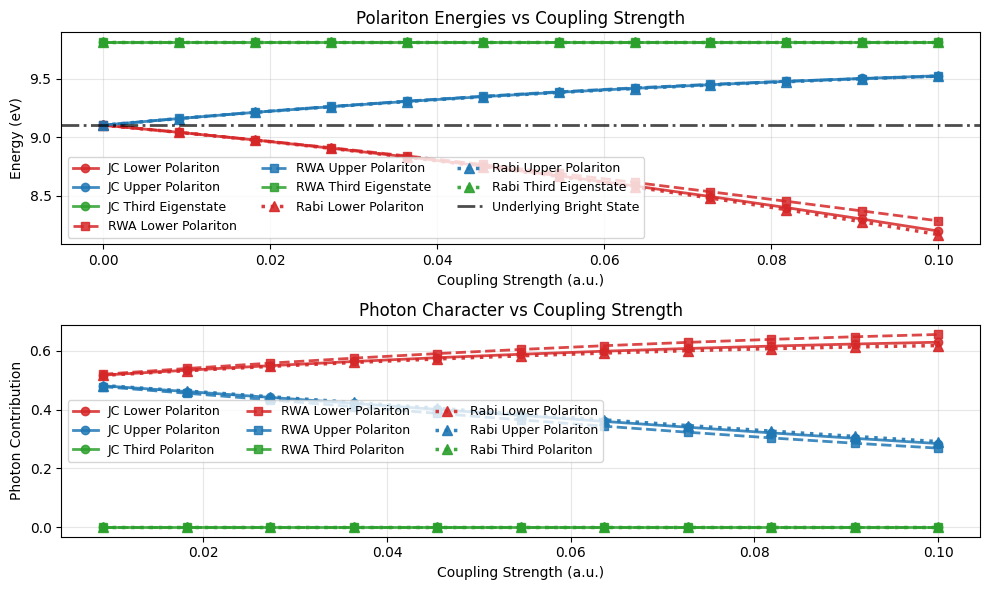

In [11]:
Rabi_energies = []
Rabi_photon_contribution = []

for lam in lambdas:
    print(f"{BLUE}Coupling lam = {lam:.3f}, au...{RESET}", end="\r")
    key['cavity_mode'] = (unit_dip * lam).reshape(3, 1)
    cav_rabi = qed.Rabi(mf, key)
    td_rabi = qed.TDA(mf, td, cav_rabi, key)
    td_rabi.nroots = 5
    td_rabi.kernel()
    print(f"Coupling: {lam:.3f} a.u., Polariton Energies: {td_rabi.e}")
    p = cav_rabi.get_mns_weight(td_rabi.mn)
    Rabi_photon_contribution.append(p)
    Rabi_energies.append(td_rabi.e)
    print(f"{YELLOW}----------------------------------------------------------------{RESET}")

Rabi_energies = np.array(Rabi_energies)
Rabi_photon_contribution = np.array(Rabi_photon_contribution)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

state_colors = ['tab:red', 'tab:blue', 'tab:green']

# JC
for i, label in enumerate([
    'Lower Polariton',
    'Upper Polariton',
    'Third Eigenstate'
]):
    ax1.plot(
        lambdas,
        JC_energies[:, i] * HF_TO_EV, color=state_colors[i], marker='o', linestyle='-',
        linewidth=2,
        markersize=6,
        alpha=0.85,
        label=f'JC {label}'
    )

# RWA
for i, label in enumerate([
    'Lower Polariton',
    'Upper Polariton',
    'Third Eigenstate'
]):
    ax1.plot(
        lambdas,
        RWA_energies[:, i] * HF_TO_EV, color=state_colors[i], marker='s', linestyle='--',
        linewidth=2,
        markersize=6,
        alpha=0.85,
        label=f'RWA {label}'
    )

# Rabi
for i, label in enumerate([
    'Lower Polariton',
    'Upper Polariton',
    'Third Eigenstate'
]):
    ax1.plot(
        lambdas,
        Rabi_energies[:, i] * HF_TO_EV, color=state_colors[i], marker='^', linestyle=':',
        linewidth=2.5,
        markersize=7,
        alpha=0.9,
        label=f'Rabi {label}'
    )

ax1.axhline(
    target_energy * HF_TO_EV, color='black', linestyle='-.',
    linewidth=2,
    alpha=0.7,
    label='Underlying Bright State'
)

ax1.set_xlabel('Coupling Strength (a.u.)')
ax1.set_ylabel('Energy (eV)')
ax1.set_title('Polariton Energies vs Coupling Strength')
ax1.legend(ncol=3, fontsize=9)
ax1.grid(alpha=0.3)


mask = lambdas >= 1e-8

# JC
for i, label in enumerate([
    'Lower Polariton',
    'Upper Polariton',
    'Third Polariton'
]):
    ax2.plot(
        lambdas[mask],
        JC_photon_contribution[:, i][mask], color=state_colors[i], marker='o', linestyle='-',
        linewidth=2,
        markersize=6,
        alpha=0.85,
        label=f'JC {label}'
    )

# RWA
for i, label in enumerate([
    'Lower Polariton',
    'Upper Polariton',
    'Third Polariton'
]):
    ax2.plot(
        lambdas[mask],
        RWA_photon_contribution[:, i][mask], color=state_colors[i], marker='s', linestyle='--',
        linewidth=2,
        markersize=6,
        alpha=0.85,
        label=f'RWA {label}'
    )

# Rabi
for i, label in enumerate([
    'Lower Polariton',
    'Upper Polariton',
    'Third Polariton'
]):
    ax2.plot(
        lambdas[mask],
        Rabi_photon_contribution[:, i][mask], color=state_colors[i], marker='^', linestyle=':',
        linewidth=2.5,
        markersize=7,
        alpha=0.9,
        label=f'Rabi {label}'
    )

ax2.set_xlabel('Coupling Strength (a.u.)')
ax2.set_ylabel('Photon Contribution')
ax2.set_title('Photon Character vs Coupling Strength')
ax2.legend(ncol=3, fontsize=9)
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

---
# 🏋️ Part 5: Recommended Exercises

To deepen your understanding of the TDA-JC model and light-matter interactions, try the following exercises:

#### **Exercise 1: Basis Set Sensitivity**
The choice of basis set can significantly impact the calculated excitation energies and transition dipoles.
*   **Task:** Rerun the ground state and TDA calculations (Part 1.1 - 1.3) using a smaller basis set like `6-31G` and a larger one like `cc-pVDZ`.
*   **Question:** How does the bright state energy ($E_{bright}$) and the transition dipole moment ($\mu_{0I}$) change? How do these changes propagate to the polariton splitting in the QED-TDA results?

#### **Exercise 2: Impact of the XC Functional**
Density Functional Theory (DFT) results depend on the exchange-correlation (XC) functional.
*   **Task:** Change the functional from `pbe0` (a hybrid functional) to `pbe` (a GGA functional) or `b3lyp`.
*   **Question:** Does the GGA functional (`pbe`) tend to underestimate or overestimate the excitation energy compared to the hybrid functional (`pbe0`)? How does this affect the resonance condition with the cavity?

#### **Exercise 3: Exploring a New Molecule (Formaldehyde)**
Apply the tutorial workflow to a different system.
*   **Task:** Replace the `ethene.xyz` geometry with Formaldehyde. You can define it directly in the code:
    ```python
    mol_geometry = """
    C   0.0000000   0.0000000   0.0000000
    O   0.0000000   0.0000000   1.2200000
    H   0.0000000   0.9400000  -0.5800000
    H   0.0000000  -0.9400000  -0.5800000
    """
    mol = gto.M(atom=mol_geometry, basis='6-311++G')
    ```
*   **Question:** Identify the brightest state for Formaldehyde. Is it at a higher or lower energy than Ethene?

#### **Exercise 4: The Effect of Detuning**
In this tutorial, we tuned the cavity frequency exactly to the electronic transition ($\delta = 0$).
*   **Task:** In Part 1.3.2, manually set `cavity_freq` to be 0.5 eV higher than the `target_energy`.
*   **Question:** Look at the resulting polariton energies and the photon contribution. How does "detuning" the cavity affect the mixing between the exciton and the photon? Does one state become "more photonic" than the other?